# BCG FDS — CodeSignal Drill  (blank → hidden solution)

**Datasets are local CSVs (no internet needed):**
`loan_applicants.csv` for the drills · `telecom_churn.csv` for the cold timed run.

**How to use:** type each exercise from the BLANK cell — no peeking. The solution is the
**collapsed cell** right under it (click the left margin / `…` to expand only after trying).

Skills: **1) Cleaning & preprocessing · 2) Querying (pandas + SQL) · 3) EDA & viz · 4) ML & modeling**

Winning patterns: split BEFORE fitting transformers · Pipeline + ColumnTransformer ·
metric chosen to the problem · working end-to-end baseline before optimizing.

In [472]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv("loan_applicants.csv")   # target = has_default
print(df.shape)
df.head()

(2000, 11)


,applicant_id,age,annual_income,employment_type,education,credit_score,loan_amount,num_dependents,months_employed,region,has_default
0,10000,44.0,32017.0,salaried,bachelor,673.0,16342.0,1,61.0,central,0
1,10001,28.0,28769.0,self-employed,bachelor,731.0,5425.0,3,87.0,south,1
2,10002,49.0,49862.0,salaried,bachelor,675.0,13948.0,3,27.0,north,0
3,10003,51.0,45521.0,self-employed,highschool,850.0,13681.0,2,47.0,central,0
4,10004,18.0,19883.0,self-employed,master,779.0,4966.0,1,16.0,central,0


---
## SKILL 1 — Cleaning & Preprocessing

### 1.1 Inspect: shape, dtypes, missingness ranked, cardinality

In [473]:
# TODO: shape, info, describe(all), missing % ranked, nunique
print(df.shape)
df.info()
df.describe(include="all")
df.isna().sum().sort_values(ascending=False)

(2000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   applicant_id     2000 non-null   int64  
 1   age              1840 non-null   float64
 2   annual_income    1900 non-null   float64
 3   employment_type  1920 non-null   str    
 4   education        2000 non-null   str    
 5   credit_score     2000 non-null   float64
 6   loan_amount      2000 non-null   float64
 7   num_dependents   2000 non-null   int64  
 8   months_employed  1760 non-null   float64
 9   region           2000 non-null   str    
 10  has_default      2000 non-null   int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 172.0 KB


months_employed    240
age                160
annual_income      100
employment_type     80
applicant_id         0
credit_score         0
education            0
loan_amount          0
num_dependents       0
region               0
has_default          0
dtype: int64

In [474]:
print(df.shape)
df.info()
display(df.describe(include="all"))
print("\nMissing % (ranked):")
print(df.isna().mean().sort_values(ascending=False))
print("\nCardinality:")
print(df.nunique().sort_values(ascending=False))

(2000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   applicant_id     2000 non-null   int64  
 1   age              1840 non-null   float64
 2   annual_income    1900 non-null   float64
 3   employment_type  1920 non-null   str    
 4   education        2000 non-null   str    
 5   credit_score     2000 non-null   float64
 6   loan_amount      2000 non-null   float64
 7   num_dependents   2000 non-null   int64  
 8   months_employed  1760 non-null   float64
 9   region           2000 non-null   str    
 10  has_default      2000 non-null   int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 172.0 KB


,applicant_id,age,annual_income,employment_type,education,credit_score,loan_amount,num_dependents,months_employed,region,has_default
count,2000.000000,1840.000000,1900.000000,1920,2000,2000.00000,2000.000000,2000.000000,1760.000000,2000,2000.000000
unique,NaN,NaN,NaN,3,4,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,salaried,bachelor,NaN,NaN,NaN,NaN,central,NaN
freq,NaN,NaN,NaN,1145,781,NaN,NaN,NaN,NaN,434,NaN
mean,10999.500000,39.553261,45792.644211,NaN,NaN,650.73600,16084.105000,1.213500,60.178977,NaN,0.198000
std,577.494589,11.526332,24420.646676,NaN,NaN,89.39242,11202.875043,1.087432,34.749413,NaN,0.398592
min,10000.000000,18.000000,8674.000000,NaN,NaN,300.00000,1551.000000,0.000000,3.000000,NaN,0.000000
25%,10499.750000,31.000000,28713.750000,NaN,NaN,590.00000,8111.250000,0.000000,35.000000,NaN,0.000000
50%,10999.500000,40.000000,40402.500000,NaN,NaN,652.00000,13383.000000,1.000000,53.000000,NaN,0.000000
75%,11499.250000,47.000000,56278.500000,NaN,NaN,709.00000,20954.250000,2.000000,79.000000,NaN,0.000000



Missing % (ranked):
months_employed    0.12
age                0.08
annual_income      0.05
employment_type    0.04
applicant_id       0.00
credit_score       0.00
education          0.00
loan_amount        0.00
num_dependents     0.00
region             0.00
has_default        0.00
dtype: float64

Cardinality:
applicant_id       2000
loan_amount        1936
annual_income      1872
credit_score        394
months_employed     163
age                  57
num_dependents        8
region                5
education             4
employment_type       3
has_default           2
dtype: int64


### 1.2 Handle missing (senior way): median for skewed numerics, mode for categoricals,
and ADD a missingness flag for the most-missing column. Work on a copy.

In [475]:
# TODO
ds = df.copy()
for col in ["age","annual_income","months_employed"]:
    ds[col] = ds[col].fillna(ds[col].median())

ds["employment_type"] = ds["employment_type"].fillna(ds["employment_type"].mode()[0])
ds["months_empoyed_missing"] = df["months_employed"].isna().astype(int)
print(ds.isna().mean().sort_values(ascending=False).head())

applicant_id       0.0
age                0.0
annual_income      0.0
employment_type    0.0
education          0.0
dtype: float64


In [476]:
d = df.copy()
d["months_employed_was_na"] = d["months_employed"].isna().astype(int)
for c in ["age","annual_income","months_employed"]:
    d[c] = d[c].fillna(d[c].median())
d["employment_type"] = d["employment_type"].fillna(d["employment_type"].mode()[0])
print(d.isna().mean().sort_values(ascending=False).head())

applicant_id       0.0
age                0.0
annual_income      0.0
employment_type    0.0
education          0.0
dtype: float64


### 1.3 Drop the useless ID column, and IQR-clip `annual_income` outliers

In [477]:
# TODO

def get_iqr(ser, s=1.5):
    q1 = ser.quantile(0.25)
    q3 = ser.quantile(0.75)
    iqr = (q1 - q3) * s 
    lo, hi = q1-iqr, q3 + iqr
    return ser.clip(lo,hi)

# ds = ds.drop("applicant_id") 
# ds["annual_income"].describe()
ds["annual_income"] = get_iqr(ds["annual_income"])

In [478]:
d = d.drop(columns=["applicant_id"])
q1,q3 = d["annual_income"].quantile([.25,.75]); iqr=q3-q1
lo,hi = q1-1.5*iqr, q3+1.5*iqr
d["annual_income"] = d["annual_income"].clip(lo,hi)
print(f"clipped income to [{lo:.0f}, {hi:.0f}]")

clipped income to [-9521, 93837]


### 1.4 Leak-free ColumnTransformer — impute+scale numerics, impute+OneHot categoricals.
**The move that scores.** Use raw `df` and let the transformer handle NaN.

In [479]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


X = df.drop(columns=["has_default"])
cats = X.select_dtypes(exclude=np.number).columns.tolist()
nums = X.select_dtypes(include=np.number).columns.tolist()

num_pip = Pipeline([("imp", SimpleImputer(missing_values=np.nan, strategy="median")),("sc", StandardScaler())])
cat_pip = Pipeline([("imp", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),("ohe",OneHotEncoder(handle_unknown="ignore"))])

ct = ColumnTransformer([("nums", num_pip, nums), ("cats", cat_pip, cats)])
print(ct)

ColumnTransformer(transformers=[('nums',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='median')),
                                                 ('sc', StandardScaler())]),
                                 ['applicant_id', 'age', 'annual_income',
                                  'credit_score', 'loan_amount',
                                  'num_dependents', 'months_employed']),
                                ('cats',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['employment_type', 'education', 'region'])])


In [480]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num = ["age","annual_income","credit_score","loan_amount","num_dependents","months_employed"]
cat = ["employment_type","education","region"]
num_pipe = Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())])
cat_pipe = Pipeline([("imp",SimpleImputer(strategy="most_frequent")),
                     ("oh",OneHotEncoder(handle_unknown="ignore"))])
pre = ColumnTransformer([("num",num_pipe,num),("cat",cat_pipe,cat)])
print(pre)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='median')),
                                                 ('sc', StandardScaler())]),
                                 ['age', 'annual_income', 'credit_score',
                                  'loan_amount', 'num_dependents',
                                  'months_employed']),
                                ('cat',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('oh',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['employment_type', 'education', 'region'])])


### 1.5 Train/test split BEFORE fitting. Stratify on target.

In [481]:
from sklearn.model_selection import train_test_split
x_tr, x_te, y_tr, y_te = train_test_split(df.drop(columns=["has_default"]), df["has_default"], stratify=df["has_default"])
print(x_tr.shape, x_te.shape, round(y_tr.mean(),3), round(y_te.mean(),3))

(1500, 10) (500, 10) 0.198 0.198


In [482]:
from sklearn.model_selection import train_test_split
features = ["age","annual_income","credit_score","loan_amount","num_dependents",
            "months_employed","employment_type","education","region"]
X = df[features]; y = df["has_default"]
X_tr,X_te,Y_tr,Y_te = train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
# print(X_tr.shape, X_te.shape, round(y_tr.mean(),3), round(y_te.mean(),3))

---
## SKILL 2 — Querying & Retrieval (pandas)

### 2.1 Filter+select: self-employed applicants with credit_score < 600 → id, income, loan_amount

In [483]:
df
# .tolist()

,applicant_id,age,annual_income,employment_type,education,credit_score,loan_amount,num_dependents,months_employed,region,has_default
0,10000,44.0,32017.0,salaried,bachelor,673.0,16342.0,1,61.0,central,0
1,10001,28.0,28769.0,self-employed,bachelor,731.0,5425.0,3,87.0,south,1
2,10002,49.0,49862.0,salaried,bachelor,675.0,13948.0,3,27.0,north,0
3,10003,51.0,45521.0,self-employed,highschool,850.0,13681.0,2,47.0,central,0
4,10004,18.0,19883.0,self-employed,master,779.0,4966.0,1,16.0,central,0
...,...,...,...,...,...,...,...,...,...,...,...
1995,11995,NaN,28584.0,salaried,highschool,518.0,16092.0,3,38.0,east,0
1996,11996,44.0,66558.0,salaried,bachelor,670.0,12387.0,2,NaN,north,0
1997,11997,39.0,35495.0,salaried,highschool,795.0,4874.0,1,51.0,central,0
1998,11998,34.0,29004.0,salaried,highschool,668.0,16203.0,0,99.0,south,1


In [484]:
a = df.loc[(df["employment_type"] == "self-employed") & (df["credit_score"] < 600), ["applicant_id", "annual_income", "loan_amount"]]

In [485]:
df.loc[(df.employment_type=="self-employed") & (df.credit_score<600),
       ["applicant_id","annual_income","loan_amount"]].head()

,applicant_id,annual_income,loan_amount
22,10022,42829.0,12332.0
26,10026,53241.0,7094.0
66,10066,65009.0,26360.0
69,10069,36388.0,14646.0
75,10075,21098.0,7263.0


In [486]:
df.columns

Index(['applicant_id', 'age', 'annual_income', 'employment_type', 'education',
       'credit_score', 'loan_amount', 'num_dependents', 'months_employed',
       'region', 'has_default'],
      dtype='str')

### 2.2 Groupby-agg: default rate, mean income, count — by employment_type & education

In [487]:
(df.groupby(by=["employment_type","education"]).agg(
    default_rate= ("has_default", "mean"),
    mean_income = ("annual_income", "mean"),
    n = ("annual_income", "size")
)
.round(3)
.sort_values("mean_income", ascending=False)
.reset_index())

,employment_type,education,default_rate,mean_income,n
0,salaried,highschool,0.190,47932.822,401
1,self-employed,bachelor,0.184,47103.945,212
2,unemployed,bachelor,0.356,46767.048,90
3,unemployed,highschool,0.377,46081.727,77
4,salaried,bachelor,0.160,45743.653,445
5,self-employed,highschool,0.194,45493.847,191
6,salaried,master,0.173,44806.430,237
7,self-employed,phd,0.000,44098.077,29
8,self-employed,master,0.191,42753.817,136
9,salaried,phd,0.274,42462.569,62


In [488]:
(df.groupby(["employment_type","education"])
   .agg(default_rate=("has_default","mean"),
        mean_income=("annual_income","mean"),
        n=("has_default","size"))
   .round(3))

default_rate  mean_income    n
employment_type education                                 
salaried        bachelor           0.160    45743.653  445
                highschool         0.190    47932.822  401
                master             0.173    44806.430  237
                phd                0.274    42462.569   62
self-employed   bachelor           0.184    47103.945  212
                highschool         0.194    45493.847  191
                master             0.191    42753.817  136
                phd                0.000    44098.077   29
unemployed      bachelor           0.356    46767.048   90
                highschool         0.377    46081.727   77
                master             0.355    41270.138   31
                phd                0.222    39727.222    9

### 2.3 sort + top-n: 5 highest loan_amount applicants

In [489]:
df.sort_values("loan_amount", ascending=False).head()

,applicant_id,age,annual_income,employment_type,education,credit_score,loan_amount,num_dependents,months_employed,region,has_default
1304,11304,37.0,188011.0,salaried,highschool,786.0,97967.0,1,101.0,east,0
1424,11424,42.0,NaN,self-employed,highschool,714.0,79676.0,1,26.0,east,0
775,10775,42.0,149847.0,salaried,highschool,714.0,78889.0,1,124.0,east,0
445,10445,22.0,147534.0,salaried,master,553.0,76058.0,0,NaN,south,1
1601,11601,54.0,134444.0,salaried,bachelor,771.0,75498.0,0,127.0,central,1


In [490]:
df.sort_values("loan_amount", ascending=False)[
    ["applicant_id","loan_amount","annual_income","has_default"]].head()

,applicant_id,loan_amount,annual_income,has_default
1304,11304,97967.0,188011.0,0
1424,11424,79676.0,NaN,0
775,10775,78889.0,149847.0,0
445,10445,76058.0,147534.0,1
1601,11601,75498.0,134444.0,1


### 2.4 New feature + pivot: loan_to_income ratio, then mean default by education × employment

In [491]:
df["loan_to_income"] = df["loan_amount"]/df["annual_income"]
df.pivot_table(columns="education", index="employment_type", values="has_default", aggfunc="mean").round(3)

education,bachelor,highschool,master,phd
employment_type,,,,
salaried,0.160,0.190,0.173,0.274
self-employed,0.184,0.194,0.191,0.000
unemployed,0.356,0.377,0.355,0.222


In [492]:
df["loan_to_income"] = df["loan_amount"]/df["annual_income"]
df.pivot_table(values="has_default", index="education",
               columns="employment_type", aggfunc="mean").round(3)

employment_type,salaried,self-employed,unemployed
education,,,
bachelor,0.160,0.184,0.356
highschool,0.190,0.194,0.377
master,0.173,0.191,0.355
phd,0.274,0.000,0.222


### 2.5 merge: region risk lookup, joined back on

In [493]:
df.columns

Index(['applicant_id', 'age', 'annual_income', 'employment_type', 'education',
       'credit_score', 'loan_amount', 'num_dependents', 'months_employed',
       'region', 'has_default', 'loan_to_income'],
      dtype='str')

In [494]:
region_risk = df.groupby("region")["has_default"].mean()
region_risk = region_risk.rename("region_risk").reset_index()
merged = df.merge(region_risk, how="inner", on="region")
merged.head()

,applicant_id,age,annual_income,employment_type,education,credit_score,loan_amount,num_dependents,months_employed,region,has_default,loan_to_income,region_risk
0,10000,44.0,32017.0,salaried,bachelor,673.0,16342.0,1,61.0,central,0,0.510416,0.198157
1,10001,28.0,28769.0,self-employed,bachelor,731.0,5425.0,3,87.0,south,1,0.188571,0.210811
2,10002,49.0,49862.0,salaried,bachelor,675.0,13948.0,3,27.0,north,0,0.279732,0.183246
3,10003,51.0,45521.0,self-employed,highschool,850.0,13681.0,2,47.0,central,0,0.300543,0.198157
4,10004,18.0,19883.0,self-employed,master,779.0,4966.0,1,16.0,central,0,0.249761,0.198157


In [495]:
risk = df.groupby("region")["has_default"].mean().rename("region_risk").reset_index()
merged = df.merge(risk, on="region", how="left")
merged[["region","region_risk"]].drop_duplicates().sort_values("region_risk")

,region,region_risk
10,west,0.178841
2,north,0.183246
0,central,0.198157
1,south,0.210811
12,east,0.218225


---
## SKILL 2b — SQL (if there's a SQL pad)

In [496]:
conn = sqlite3.connect(":memory:")
df.to_sql("loans", conn, index=False, if_exists="replace")
def q(sql): return pd.read_sql(sql, conn)
q("SELECT COUNT(*) AS n FROM loans")

,n
0,2000


### S.1 Default rate, avg income, count by employment_type — order by default rate desc

In [497]:
q("""
SELECT employment_type, 
  AVG(has_default) AS default_rate,
  AVG(annual_income) AS avg_income,
  COUNT(*) AS n
FROM loans
GROUP BY employment_type
ORDER BY default_rate DESC
""")

,employment_type,default_rate,avg_income,n
0,unemployed,0.357488,45375.439394,207
1,NaN,0.187500,44892.181818,80
2,self-employed,0.179577,45355.025974,568
3,salaried,0.179039,46149.751381,1145


In [498]:
q("""
SELECT employment_type,
       AVG(has_default) AS default_rate,
       AVG(annual_income) AS avg_income,
       COUNT(*) AS n
FROM loans
GROUP BY employment_type
ORDER BY default_rate DESC
""")

,employment_type,default_rate,avg_income,n
0,unemployed,0.357488,45375.439394,207
1,NaN,0.187500,44892.181818,80
2,self-employed,0.179577,45355.025974,568
3,salaried,0.179039,46149.751381,1145


### S.2 Filter: defaulters with credit_score < 580

In [499]:
# TODO
pass

In [500]:
q("""
SELECT applicant_id, credit_score, loan_amount
FROM loans
WHERE has_default=1 AND credit_score < 580
LIMIT 5
""")

,applicant_id,credit_score,loan_amount
0,10008,575.0,18676.0
1,10023,511.0,21590.0
2,10024,570.0,10681.0
3,10025,563.0,11214.0
4,10044,563.0,8774.0


### S.3 Window: rank applicants by loan_amount within each region

In [501]:
# TODO
pass

In [502]:
q("""
SELECT region, applicant_id, loan_amount,
       RANK() OVER (PARTITION BY region ORDER BY loan_amount DESC) AS rk
FROM loans
ORDER BY region, rk
LIMIT 10
""")

,region,applicant_id,loan_amount,rk
0,central,11601,75498.0,1
1,central,11218,58234.0,2
2,central,11068,55283.0,3
3,central,11002,50407.0,4
4,central,10563,49717.0,5
5,central,11494,43635.0,6
6,central,10959,43156.0,7
7,central,10852,42449.0,8
8,central,10162,42318.0,9
9,central,10991,41545.0,10


---
## SKILL 3 — EDA & Visualization

### 3.1 The fixed 6-move opener — one reflex
shape · info · describe · missing% · nunique · target balance

In [503]:
print(df["has_default"].value_counts(normalize=True))

has_default
0    0.802
1    0.198
Name: proportion, dtype: float64


In [504]:
print(df.shape); df.info()
display(df.describe(include="all"))
print(df.isna().mean().sort_values(ascending=False))
print(df.nunique())
print(df["has_default"].value_counts(normalize=True))

(2000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   applicant_id     2000 non-null   int64  
 1   age              1840 non-null   float64
 2   annual_income    1900 non-null   float64
 3   employment_type  1920 non-null   str    
 4   education        2000 non-null   str    
 5   credit_score     2000 non-null   float64
 6   loan_amount      2000 non-null   float64
 7   num_dependents   2000 non-null   int64  
 8   months_employed  1760 non-null   float64
 9   region           2000 non-null   str    
 10  has_default      2000 non-null   int64  
 11  loan_to_income   1900 non-null   float64
dtypes: float64(6), int64(3), str(3)
memory usage: 187.6 KB


,applicant_id,age,annual_income,employment_type,education,credit_score,loan_amount,num_dependents,months_employed,region,has_default,loan_to_income
count,2000.000000,1840.000000,1900.000000,1920,2000,2000.00000,2000.000000,2000.000000,1760.000000,2000,2000.000000,1900.000000
unique,NaN,NaN,NaN,3,4,NaN,NaN,NaN,NaN,5,NaN,NaN
top,NaN,NaN,NaN,salaried,bachelor,NaN,NaN,NaN,NaN,central,NaN,NaN
freq,NaN,NaN,NaN,1145,781,NaN,NaN,NaN,NaN,434,NaN,NaN
mean,10999.500000,39.553261,45792.644211,NaN,NaN,650.73600,16084.105000,1.213500,60.178977,NaN,0.198000,0.351155
std,577.494589,11.526332,24420.646676,NaN,NaN,89.39242,11202.875043,1.087432,34.749413,NaN,0.398592,0.143094
min,10000.000000,18.000000,8674.000000,NaN,NaN,300.00000,1551.000000,0.000000,3.000000,NaN,0.000000,0.100517
25%,10499.750000,31.000000,28713.750000,NaN,NaN,590.00000,8111.250000,0.000000,35.000000,NaN,0.000000,0.225359
50%,10999.500000,40.000000,40402.500000,NaN,NaN,652.00000,13383.000000,1.000000,53.000000,NaN,0.000000,0.351941
75%,11499.250000,47.000000,56278.500000,NaN,NaN,709.00000,20954.250000,2.000000,79.000000,NaN,0.000000,0.475524


months_employed    0.12
age                0.08
loan_to_income     0.05
annual_income      0.05
employment_type    0.04
applicant_id       0.00
education          0.00
credit_score       0.00
num_dependents     0.00
loan_amount        0.00
region             0.00
has_default        0.00
dtype: float64
applicant_id       2000
age                  57
annual_income      1872
employment_type       3
education             4
credit_score        394
loan_amount        1936
num_dependents        8
months_employed     163
region                5
has_default           2
loan_to_income     1900
dtype: int64
has_default
0    0.802
1    0.198
Name: proportion, dtype: float64


### 3.2 Correlation heatmap (numeric only)

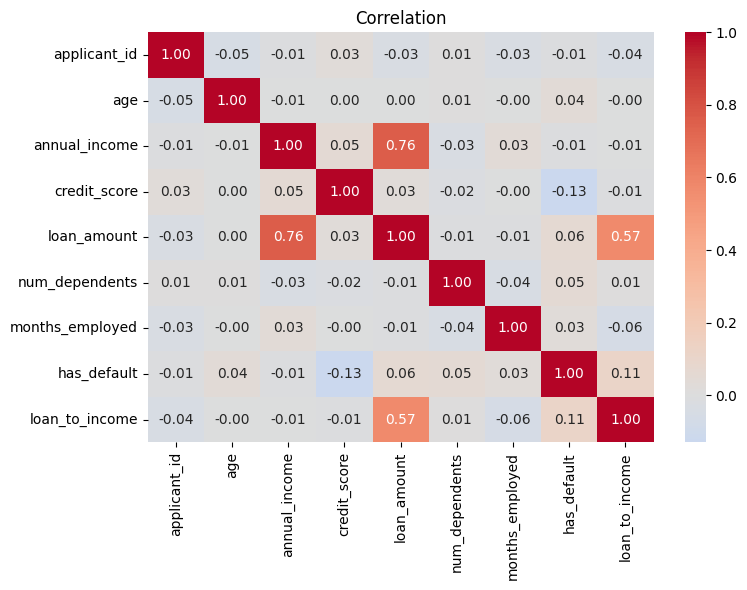

In [505]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation"); plt.tight_layout(); plt.show()

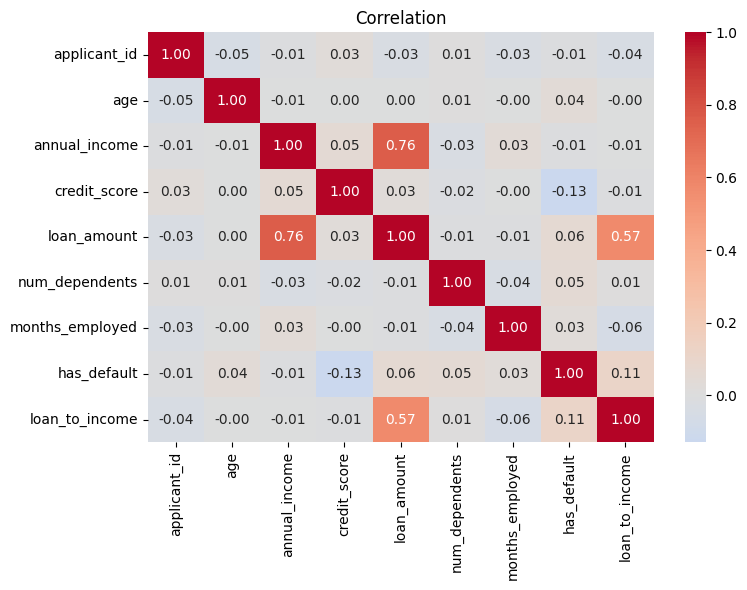

In [506]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation"); plt.tight_layout(); plt.show()

### 3.3 Distribution + relationship: income histogram, and default rate by employment_type

<Axes: xlabel='employment_type', ylabel='has_default'>

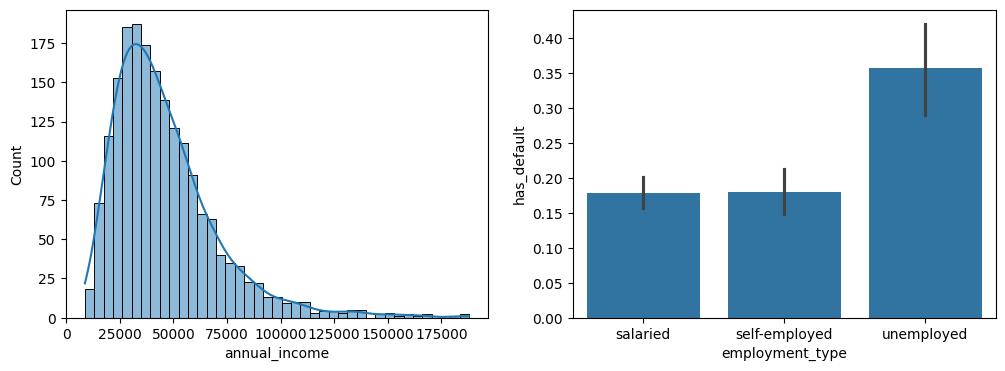

In [507]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df.annual_income, kde=True, pmax=10, ax=ax[0])
sns.barplot(df, x="employment_type", y="has_default")

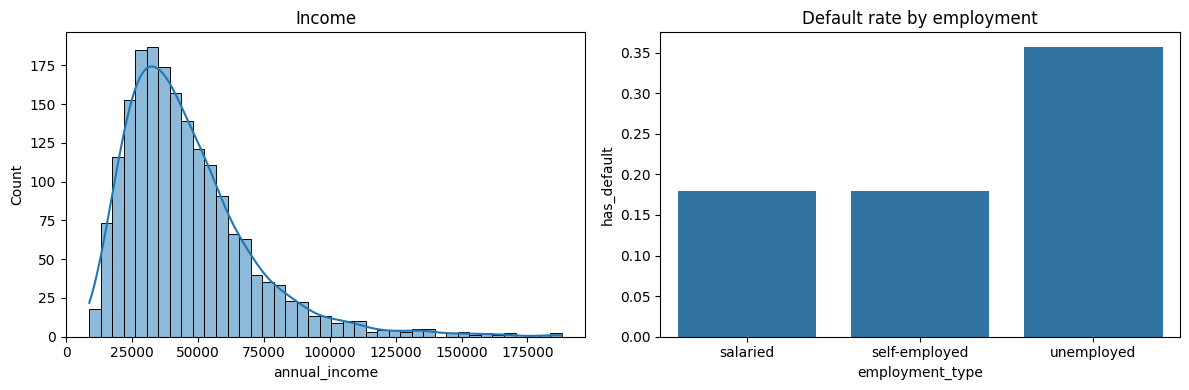

In [508]:
fig,ax = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df["annual_income"].dropna(), kde=True, ax=ax[0]); ax[0].set_title("Income")
sns.barplot(data=df, x="employment_type", y="has_default", ax=ax[1], errorbar=None)
ax[1].set_title("Default rate by employment"); plt.tight_layout(); plt.show()

### 3.4 Categorical vs target: normalized crosstab (education → default)

In [509]:
pd.crosstab

<function pandas.crosstab(index, columns, values=None, rownames=None, colnames=None, aggfunc=None, margins: 'bool' = False, margins_name: 'Hashable' = 'All', dropna: 'bool' = True, normalize: "bool | Literal[0, 1, 'all', 'index', 'columns']" = False) -> 'DataFrame'>

In [510]:
pd.crosstab(df["education"], df["has_default"], normalize="index").round(3)

has_default,0,1
education,,
bachelor,0.807,0.193
highschool,0.788,0.212
master,0.811,0.189
phd,0.819,0.181


---
## SKILL 4 — ML & Predictive Modeling

### 4.1 Full Pipeline (pre + LogisticRegression), fit on split

In [511]:
from sklearn.linear_model import LogisticRegression
full = Pipeline([("pre", ct), ("log", LogisticRegression())])
full.fit(x_tr, y_tr)
print("Train acc", round(full.score(x_tr, y_tr),3))
print("Train acc", round(full.score(x_te, y_te),3))

Train acc 0.801
Train acc 0.808


In [512]:
from sklearn.linear_model import LogisticRegression
clf = Pipeline([("pre",pre),("model",LogisticRegression(max_iter=1000))]).fit(X_tr,Y_tr)
print("train acc", round(clf.score(X_tr,Y_tr),3))
print("test  acc", round(clf.score(X_te,Y_te),3))

train acc 0.804
test  acc 0.802


### 4.2 Cross-validation — ROC-AUC mean ± std (target is imbalanced ~20%)

In [513]:
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(full, x_tr, y_tr, cv=5) #, scoring="roc_auc")
cvs = cross_val_score(full, x_tr, y_tr, cv=5, scoring="roc_auc")
# plt.plot(cvs)
print(f"ROC-AUC {cvs.mean():.3f} + std {cvs.std():.3f}")

ROC-AUC 0.615 + std 0.024


In [514]:
from sklearn.model_selection import cross_val_score
s = cross_val_score(clf, X_tr, Y_tr, cv=5, scoring="roc_auc")
print(f"ROC-AUC {s.mean():.3f} +/- {s.std():.3f}")

ROC-AUC 0.627 +/- 0.035


### 4.3 Full eval: classification_report, confusion matrix, AUC. Say WHY AUC/F1 over accuracy.

              precision    recall  f1-score   support

           0       0.81      1.00      0.89       401
           1       0.80      0.04      0.08        99

    accuracy                           0.81       500
   macro avg       0.80      0.52      0.48       500
weighted avg       0.81      0.81      0.73       500

ROC-AUC: 0.52


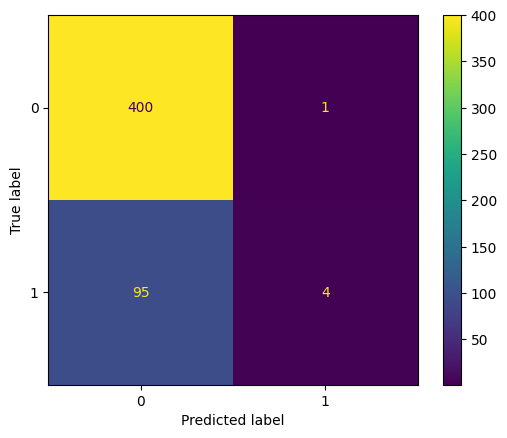

In [515]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

y_pred = full.predict(x_te)
rep = classification_report(y_te, y_pred)
print(rep)
print(f"ROC-AUC: {roc_auc_score(y_te, y_pred):.2}")
cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm).plot();plt.show()

              precision    recall  f1-score   support

           0       0.81      0.99      0.89       321
           1       0.50      0.04      0.07        79

    accuracy                           0.80       400
   macro avg       0.65      0.51      0.48       400
weighted avg       0.75      0.80      0.73       400

ROC-AUC 0.613


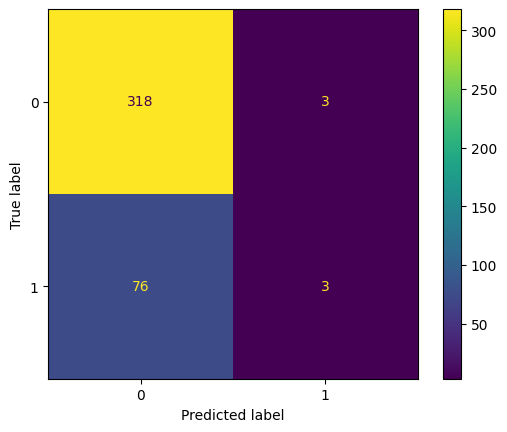

In [516]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
y_pred = clf.predict(X_te); y_proba = clf.predict_proba(X_te)[:,1]
print(classification_report(Y_te, y_pred))
print("ROC-AUC", round(roc_auc_score(Y_te, y_proba),3))
ConfusionMatrixDisplay(confusion_matrix(Y_te,y_pred)).plot(); plt.show()

### 4.4 Compare LogisticRegression vs RandomForest by CV AUC

In [530]:
from sklearn.ensemble import RandomForestClassifier
rafopip = Pipeline(steps=[("pre", ct), ("rand", RandomForestClassifier(n_estimators=1))])
rafopip.fit(x_tr, y_tr)
for fier in [full, rafopip]:
    s = cross_val_score(fier, x_tr, y_tr, cv=5, scoring="roc_auc")
    print(f"{name:8s} AUC {s.mean():.3f} +/- {s.std():.3f}")
    print(roc_auc_score(y_tr, fier.predict(x_tr)))
    print(roc_auc_score(y_te, fier.predict(x_te)))

rf       AUC 0.615 +/- 0.024
0.5029723670621427
0.5189551374090028
rf       AUC 0.529 +/- 0.016
0.8105787719254053
0.5465251013879443


In [519]:
from sklearn.ensemble import RandomForestClassifier
for name,m in {"logreg":LogisticRegression(max_iter=1000),
               "rf":RandomForestClassifier(n_estimators=100,random_state=42)}.items():
    pipe = Pipeline([("pre",pre),("model",m)])
    s = cross_val_score(pipe, X_tr, Y_tr, cv=5, scoring="roc_auc")
    print(f"{name:8s} AUC {s.mean():.3f} +/- {s.std():.3f}")

logreg   AUC 0.627 +/- 0.035
rf       AUC 0.606 +/- 0.026


### 4.5 Feature importances from the fitted ColumnTransformer (interpretation = FDS edge)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = Pipeline([("pre", ct), ("model", RandomForestClassifier(n_estimators=200,random_state=42))]).fit(x_tr, y_tr)
names = rf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_.round(3), index=names)
imp.sort_values(ascending=False)

nums__credit_score                     0.162
nums__annual_income                    0.134
nums__loan_amount                      0.132
nums__applicant_id                     0.128
nums__months_employed                  0.114
nums__age                              0.106
nums__num_dependents                   0.052
cats__employment_type_unemployed       0.020
cats__education_highschool             0.016
cats__education_master                 0.015
cats__education_bachelor               0.015
cats__region_south                     0.015
cats__region_west                      0.015
cats__region_north                     0.014
cats__region_central                   0.014
cats__region_east                      0.014
cats__employment_type_salaried         0.013
cats__employment_type_self-employed    0.012
cats__education_phd                    0.008
dtype: float64

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = Pipeline([("pre",pre),("model",
        RandomForestClassifier(n_estimators=200,random_state=42))]).fit(X_tr,y_tr)
names = rf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names)
imp.sort_values(ascending=False).head(10)

num__credit_score                  0.187673
num__loan_amount                   0.155632
num__annual_income                 0.152712
num__months_employed               0.137603
num__age                           0.124233
num__num_dependents                0.056974
cat__employment_type_unemployed    0.020514
cat__education_highschool          0.018181
cat__education_bachelor            0.017227
cat__region_central                0.016710
dtype: float64

---
## ⏱ TIMED RUN — 70 min, COLD dataset (no solutions, on purpose)

`telecom_churn.csv`, target = **churn**. This is the real rehearsal: EDA → clean → model → evaluate.

**Watch for the gotcha:** `total_charges` is stored as *text* with some blank `" "` values —
you must coerce it (`pd.to_numeric(..., errors="coerce")`) then impute. Drop `customer_id`.
Get a working end-to-end baseline first, improve only if time remains.

In [ ]:
tc = pd.read_csv("telecom_churn.csv")
print(tc.shape); print(tc.dtypes)
tc.head()
# GO. Start your 70-min timer.

(1500, 9)
customer_id             str
tenure_months         int64
monthly_charges     float64
total_charges           str
contract_type           str
payment_method          str
internet_service        str
senior_citizen        int64
churn                 int64
dtype: object


,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,senior_citizen,churn
0,C00000,40,19.85,767.32,month-to-month,credit-card,fiber-optic,0,1
1,C00001,2,67.65,140.91,one-year,bank-transfer,fiber-optic,1,0
2,C00002,9,119.06,1174.03,one-year,mailed-check,fiber-optic,0,1
3,C00003,58,45.40,,month-to-month,credit-card,fiber-optic,0,1
4,C00004,30,67.95,2231.17,month-to-month,mailed-check,none,0,0


In [ ]:
# How to do a gridsearch
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# proio = ColumnTransformer([("cols", col, columnames)])

gpip = Pipeline([("pre", pre), ("model", GradientBoostingClassifier(n_estimators=200))])

grid = GridSearchCV(gpip, param_grid={"model__n_estimators": [1,100,200], "model__learning_rate": [0.1, 0.01, 0.001], "model__max_depth": [3,30]}, cv=5, scoring="roc_auc")
grid.fit(x_tr, y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...mators=200))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.1, 0.01, ...], 'model__max_depth': [3, 30], 'model__n_estimators': [1, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [ ]:
grid.best_params_


{'model__learning_rate': 0.01,
 'model__max_depth': 3,
 'model__n_estimators': 50}

: 

In [544]:
grid.best_params_
est = grid.best_estimator_
roca = cross_val_score(est, x_tr, y_tr, cv=5, scoring="roc_auc")
print(roca.mean(), end=" ")
print("+-", roca.std())

0.6352597522094849 +- 0.03082587857670778
